In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# ===== GLOBAL PATHS =====

from pathlib import Path

BASE_DIR = Path("/content/drive/MyDrive/deepfake_audio")
DATA_DIR = BASE_DIR / "data" / "LA"

TRAIN_DIR = DATA_DIR / "ASVspoof2019_LA_train"
DEV_DIR   = DATA_DIR / "ASVspoof2019_LA_dev"

MODEL_DIR = BASE_DIR / "models"
RESULTS_DIR = BASE_DIR / "results"

print("BASE_DIR exists:", BASE_DIR.exists())
print("DATA_DIR exists:", DATA_DIR.exists())
print("MODEL_DIR exists:", MODEL_DIR.exists())
print("RESULTS_DIR exists:", RESULTS_DIR.exists())


In [ ]:
# ===== FAST RESUME CELL (run after restart) =====

import pandas as pd
import torch

# Load best model
model_path = MODEL_DIR / "spec_cnn_bigger_best.pt"
print("Model exists:", model_path.exists())

# Load saved DEV scores
score_path = RESULTS_DIR / "dev_scores_with_meta.csv"
print("Score file exists:", score_path.exists())

if score_path.exists():
    dev_scores_df = pd.read_csv(score_path)
    print("Loaded saved DEV scores:", dev_scores_df.shape)


In [2]:
# ===== VERIFY DATA PATHS =====

PROTOCOL_DIR = DATA_DIR / "ASVspoof2019_LA_cm_protocols"

print("BASE_DIR exists:", BASE_DIR.exists())
print("DATA_DIR exists:", DATA_DIR.exists())
print("TRAIN_DIR exists:", TRAIN_DIR.exists())
print("DEV_DIR exists:", DEV_DIR.exists())
print("PROTOCOL_DIR exists:", PROTOCOL_DIR.exists())



BASE_DIR exists: True
DATA_DIR exists: True
TRAIN_DIR exists: True
PROTOCOL_DIR exists: True


In [3]:
# Find all FLAC files in the training set
audio_files = list(TRAIN_DIR.glob("**/*.flac"))
print("Number of FLAC files:", len(audio_files))


Number of FLAC files: 25380


In [4]:
import librosa

sample_audio = audio_files[0]
audio, sr = librosa.load(sample_audio, sr=16000)

print("Audio shape:", audio.shape)
print("Sample rate:", sr)


Audio shape: (41727,)
Sample rate: 16000


In [5]:
pip install librosa numpy pandas matplotlib soundfile


In [6]:
import librosa

sample_audio = audio_files[0]
audio, sr = librosa.load(sample_audio, sr=16000)

print("Audio shape:", audio.shape)
print("Sample rate:", sr)


Audio shape: (41727,)
Sample rate: 16000


In [7]:
import numpy as np

mfccs = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=13)
print("MFCC shape:", mfccs.shape)


MFCC shape: (13, 82)


In [8]:
# Aggregate MFCCs over time
mfcc_mean = mfccs.mean(axis=1)
mfcc_std = mfccs.std(axis=1)

print("MFCC mean shape:", mfcc_mean.shape)
print("MFCC std shape:", mfcc_std.shape)

# Final MFCC feature vector
mfcc_features = np.concatenate([mfcc_mean, mfcc_std])
print("Final MFCC feature vector shape:", mfcc_features.shape)


MFCC mean shape: (13,)
MFCC std shape: (13,)
Final MFCC feature vector shape: (26,)


In [9]:
# Spectral features
spec_centroid = librosa.feature.spectral_centroid(y=audio, sr=sr)
spec_rolloff = librosa.feature.spectral_rolloff(y=audio, sr=sr)
zcr = librosa.feature.zero_crossing_rate(audio)

spectral_features = np.array([
    spec_centroid.mean(),
    spec_centroid.std(),
    spec_rolloff.mean(),
    zcr.mean()
])

print("Spectral features shape:", spectral_features.shape)


Spectral features shape: (4,)


In [10]:
final_features = np.concatenate([mfcc_features, spectral_features])
print("Final feature vector shape:", final_features.shape)


Final feature vector shape: (30,)


In [11]:
from pathlib import Path

BASE = Path("/content/drive/MyDrive")

for p in BASE.glob("**/ASVspoof2019_LA_train"):
    print(p)


/content/drive/MyDrive/deepfake_audio/data/LA/ASVspoof2019_LA_train


In [12]:
import librosa
import numpy as np

sample_audio = audio_files[0]
audio, sr = librosa.load(sample_audio, sr=16000)

mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=13)

mfcc_mean = mfcc.mean(axis=1)
mfcc_std = mfcc.std(axis=1)

feature_vector = np.concatenate([mfcc_mean, mfcc_std])

print("Feature vector shape:", feature_vector.shape)


Feature vector shape: (26,)


In [13]:
from pathlib import Path

BASE_DIR = Path("/content/drive/MyDrive/deepfake_audio")
DATA_DIR = BASE_DIR / "data" / "LA"
PROTOCOL_DIR = DATA_DIR / "ASVspoof2019_LA_cm_protocols"

protocol_file = PROTOCOL_DIR / "ASVspoof2019.LA.cm.train.trn.txt"

print("Protocol file exists:", protocol_file.exists())


Protocol file exists: True


In [14]:
label_map = {}

with open(protocol_file) as f:
    for line in f:
        parts = line.strip().split()
        audio_id = parts[1]   # e.g., LA_T_1138215
        label = parts[4]      # bonafide or spoof
        label_map[audio_id] = label

print("Number of labels:", len(label_map))


Number of labels: 25380


In [15]:
import librosa
import numpy as np

def extract_features(audio_path, sr=16000, n_mfcc=13):
    # Load audio
    audio, sr = librosa.load(audio_path, sr=sr)

    # MFCCs
    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=n_mfcc)
    mfcc_mean = mfcc.mean(axis=1)
    mfcc_std = mfcc.std(axis=1)

    # Combine features
    feature_vector = np.concatenate([mfcc_mean, mfcc_std])

    return feature_vector


In [16]:
!cp -r /content/drive/MyDrive/deepfake_audio/data/LA/ASVspoof2019_LA_dev /content/


^C


In [35]:
from pathlib import Path

TRAIN_DIR = Path("/content/drive/MyDrive/deepfake_audio/data/LA/ASVspoof2019_LA_train")
AUDIO_DIR = TRAIN_DIR / "flac"

audio_files = list(AUDIO_DIR.glob("*.flac"))
print("Number of audio files:", len(audio_files))

Number of audio files: 25380


In [18]:
from pathlib import Path
import numpy as np
from tqdm import tqdm

CACHE_DIR = Path("/content/drive/MyDrive/deepfake_audio/cache")
CACHE_DIR.mkdir(parents=True, exist_ok=True)

X_cache = CACHE_DIR / "X_train_mfcc.npy"
y_cache = CACHE_DIR / "y_train_mfcc.npy"

if X_cache.exists():
    print("Loading cached MFCC features...")
    X = np.load(X_cache)
    y = np.load(y_cache)
    print("Loaded:", X.shape)

else:
    print("Extracting TRAIN features (first-time only)...")

    X = []
    y = []

    for audio_path in tqdm(audio_files):
        audio_id = audio_path.stem
        label = label_map[audio_id]

        features = extract_features(audio_path)
        X.append(features)
        y.append(0 if label == "bonafide" else 1)

    X = np.array(X)
    y = np.array(y)

    np.save(X_cache, X)
    np.save(y_cache, y)

    print("Saved TRAIN features to cache.")


Loading cached MFCC features...
Loaded: (25380, 26)


In [19]:
from pathlib import Path

FEATURES_DIR = Path("/content/drive/MyDrive/deepfake_audio/features")
FEATURES_DIR.mkdir(parents=True, exist_ok=True)

print("Features dir exists:", FEATURES_DIR.exists())


Features dir exists: True


In [20]:
print("X length:", len(X))
print("y length:", len(y))
print("audio_files length:", len(audio_files))


X length: 25380
y length: 25380
audio_files length: 25380


In [21]:
import numpy as np

unique, counts = np.unique(y, return_counts=True)
print(dict(zip(unique, counts)))


{np.int64(0): np.int64(2580), np.int64(1): np.int64(22800)}


In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [23]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

model.fit(X_train, y_train)


LogisticRegression(class_weight='balanced', max_iter=1000)

In [24]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.38      0.88      0.53       516
           1       0.98      0.83      0.90      4560

    accuracy                           0.84      5076
   macro avg       0.68      0.86      0.72      5076
weighted avg       0.92      0.84      0.87      5076

[[ 456   60]
 [ 753 3807]]


In [25]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

svm = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", class_weight="balanced"))
])

svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

print(classification_report(y_test, y_pred_svm))
print(confusion_matrix(y_test, y_pred_svm))


              precision    recall  f1-score   support

           0       0.76      0.98      0.85       516
           1       1.00      0.96      0.98      4560

    accuracy                           0.97      5076
   macro avg       0.88      0.97      0.92      5076
weighted avg       0.97      0.97      0.97      5076

[[ 504   12]
 [ 162 4398]]


In [26]:
# CELL: Paths for DEV split + protocol loading helpers

from pathlib import Path
import pandas as pd
import numpy as np

BASE_DIR = Path("/content/drive/MyDrive/deepfake_audio")
DATA_DIR = BASE_DIR / "data" / "LA"
PROTOCOL_DIR = DATA_DIR / "ASVspoof2019_LA_cm_protocols"

TRAIN_DIR = DATA_DIR / "ASVspoof2019_LA_train"
DEV_DIR   = Path("/content/ASVspoof2019_LA_dev")  # ← updated here

train_protocol = PROTOCOL_DIR / "ASVspoof2019.LA.cm.train.trn.txt"
dev_protocol   = PROTOCOL_DIR / "ASVspoof2019.LA.cm.dev.trl.txt"


print("TRAIN_DIR exists:", TRAIN_DIR.exists())
print("DEV_DIR exists:", DEV_DIR.exists())
print("train_protocol exists:", train_protocol.exists())
print("dev_protocol exists:", dev_protocol.exists())

def load_cm_protocol(protocol_path: Path) -> pd.DataFrame:
    """
    ASVspoof2019 LA CM protocol format (space-separated):
    speaker_id  file_id  env_id  attack_id  label
    """
    rows = []
    with open(protocol_path, "r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            speaker_id, file_id, env_id, attack_id, label = parts[:5]
            rows.append({
                "speaker_id": speaker_id,
                "file_id": file_id,
                "env_id": env_id,
                "attack_id": attack_id,
                "label_str": label
            })
    df = pd.DataFrame(rows)
    return df

train_df = load_cm_protocol(train_protocol)
dev_df   = load_cm_protocol(dev_protocol)

print("Train protocol rows:", len(train_df))
print("Dev protocol rows:", len(dev_df))
print("Train label counts:\n", train_df["label_str"].value_counts())
print("Dev label counts:\n", dev_df["label_str"].value_counts())


TRAIN_DIR exists: True
DEV_DIR exists: True
train_protocol exists: True
dev_protocol exists: True
Train protocol rows: 25380
Dev protocol rows: 24844
Train label counts:
 label_str
spoof       22800
bonafide     2580
Name: count, dtype: int64
Dev label counts:
 label_str
spoof       22296
bonafide     2548
Name: count, dtype: int64


In [27]:
from tqdm import tqdm

label_to_y = {"bonafide": 0, "spoof": 1}

def resolve_audio_path(split_dir: Path, file_id: str) -> Path:
    p = split_dir / "flac" / f"{file_id}.flac"
    if p.exists():
        return p
    hits = list(split_dir.glob(f"**/{file_id}.flac"))
    return hits[0] if len(hits) else None

def build_xy(df, split_dir, desc):
    X_list, y_list, used_ids, missing = [], [], [], 0

    for file_id, label_str in tqdm(
        zip(df["file_id"].values, df["label_str"].values),
        total=len(df),
        desc=desc
    ):
        y = label_to_y.get(label_str)
        if y is None:
            continue

        audio_path = resolve_audio_path(split_dir, file_id)
        if audio_path is None:
            missing += 1
            continue

        feats = extract_features(audio_path)
        X_list.append(feats)
        y_list.append(y)
        used_ids.append(file_id)

    X = np.vstack(X_list).astype(np.float32)
    y = np.array(y_list).astype(np.int64)

    print(f"{desc}: built X={X.shape}, y={y.shape}, missing_files={missing}")
    return X, y, used_ids


In [28]:
# CELL: Build or Load TRAIN and DEV feature matrices (with caching)

from pathlib import Path
import numpy as np

FEATURE_DIR = Path("/content/drive/MyDrive/deepfake_audio/features")
FEATURE_DIR.mkdir(parents=True, exist_ok=True)

train_npz = FEATURE_DIR / "train_features.npz"
dev_npz   = FEATURE_DIR / "dev_features.npz"

# -------------------------
# TRAIN
# -------------------------
if train_npz.exists():
    print("Loading cached TRAIN features...")
    train_data = np.load(train_npz)
    X_train = train_data["X"]
    y_train = train_data["y"]
    print("Loaded TRAIN:", X_train.shape, y_train.shape)

else:
    print("Extracting TRAIN features (first-time only)...")
    X_train, y_train, _ = build_xy(train_df, TRAIN_DIR, "Extract TRAIN features")
    np.savez(train_npz, X=X_train, y=y_train)
    print("Saved TRAIN features:", X_train.shape, y_train.shape)

# -------------------------
# DEV
# -------------------------
if dev_npz.exists():
    print("Loading cached DEV features...")
    dev_data = np.load(dev_npz)
    X_dev = dev_data["X"]
    y_dev = dev_data["y"]
    print("Loaded DEV:", X_dev.shape, y_dev.shape)

else:
    print("Extracting DEV features (first-time only)...")
    X_dev, y_dev, _ = build_xy(dev_df, DEV_DIR, "Extract DEV features")
    np.savez(dev_npz, X=X_dev, y=y_dev)
    print("Saved DEV features:", X_dev.shape, y_dev.shape)

print("\nFinal shapes:")
print("X_train:", X_train.shape)
print("X_dev:", X_dev.shape)


Loading cached TRAIN features...
Loaded TRAIN: (25380, 26) (25380,)
Loading cached DEV features...
Loaded DEV: (24844, 26) (24844,)

Final shapes:
X_train: (25380, 26)
X_dev: (24844, 26)


In [29]:
# CELL: Train models on TRAIN split only (baseline LR + SVM)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# Logistic Regression baseline
lr = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=2000, class_weight="balanced"))
])
lr.fit(X_train, y_train)

# SVM baseline (use decision_function for scores; probability=True is slower)
svm = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", class_weight="balanced"))
])
svm.fit(X_train, y_train)

print("Trained LR and SVM on official TRAIN split.")


Trained LR and SVM on official TRAIN split.



=== Logistic Regression (MFCC stats) on DEV ===
AUC: 0.9118
EER: 0.1723  (threshold=0.505145)
Confusion matrix @EER threshold:
 [[ 2109   439]
 [ 3841 18455]]

Classification report @EER threshold:
               precision    recall  f1-score   support

    bonafide       0.35      0.83      0.50      2548
       spoof       0.98      0.83      0.90     22296

    accuracy                           0.83     24844
   macro avg       0.67      0.83      0.70     24844
weighted avg       0.91      0.83      0.86     24844



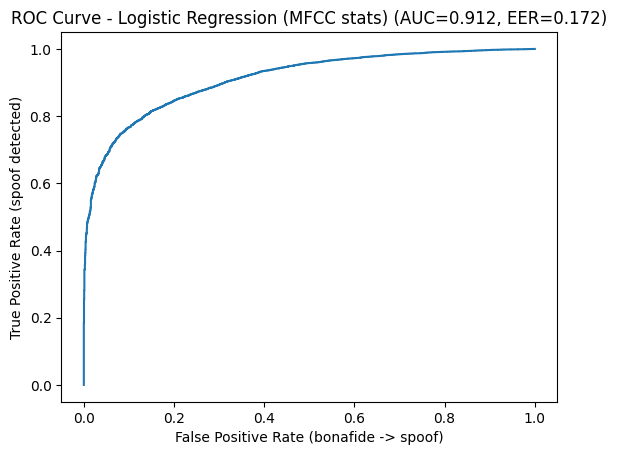


=== SVM RBF (MFCC stats) on DEV ===
AUC: 0.9472
EER: 0.1160  (threshold=0.670553)
Confusion matrix @EER threshold:
 [[ 2253   295]
 [ 2590 19706]]

Classification report @EER threshold:
               precision    recall  f1-score   support

    bonafide       0.47      0.88      0.61      2548
       spoof       0.99      0.88      0.93     22296

    accuracy                           0.88     24844
   macro avg       0.73      0.88      0.77     24844
weighted avg       0.93      0.88      0.90     24844



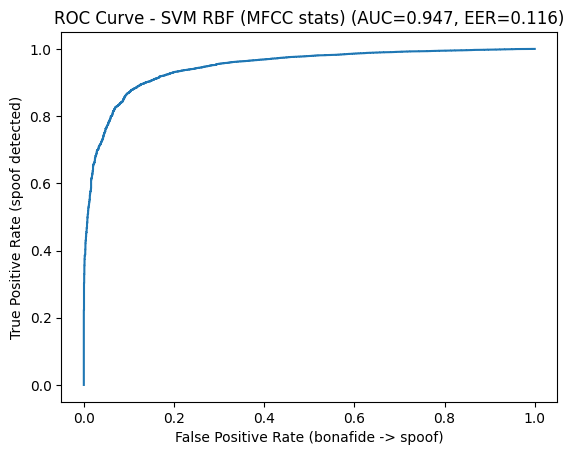

In [30]:
# CELL: EER + ROC/AUC evaluation on DEV split (research-aligned metrics)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix, classification_report

def get_scores(model, X):
    """
    Return continuous scores where higher => more likely spoof (positive class=1).
    Works for pipelines too.
    """
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, "decision_function"):
        return model.decision_function(X)
    # fallback (not ideal): map hard predictions to {0,1}
    return model.predict(X).astype(float)

def compute_eer(y_true, scores):
    """
    Computes EER and the threshold at which FAR ~= FRR.
    y_true: 0=bonafide, 1=spoof
    scores: higher => more spoof
    """
    fpr, tpr, thresholds = roc_curve(y_true, scores, pos_label=1)
    fnr = 1 - tpr

    # Find point where FPR and FNR are closest
    idx = np.nanargmin(np.abs(fpr - fnr))
    eer = (fpr[idx] + fnr[idx]) / 2.0
    thr = thresholds[idx]
    return eer, thr, fpr, tpr, thresholds

def eval_model(name, model, X, y):
    scores = get_scores(model, X)
    auc = roc_auc_score(y, scores)

    eer, thr, fpr, tpr, _ = compute_eer(y, scores)

    # Predictions using EER threshold
    y_pred = (scores >= thr).astype(int)

    print(f"\n=== {name} on DEV ===")
    print(f"AUC: {auc:.4f}")
    print(f"EER: {eer:.4f}  (threshold={thr:.6f})")
    print("Confusion matrix @EER threshold:\n", confusion_matrix(y, y_pred))
    print("\nClassification report @EER threshold:\n", classification_report(y, y_pred, target_names=["bonafide", "spoof"]))

    # ROC plot
    plt.figure()
    plt.plot(fpr, tpr)
    plt.xlabel("False Positive Rate (bonafide -> spoof)")
    plt.ylabel("True Positive Rate (spoof detected)")
    plt.title(f"ROC Curve - {name} (AUC={auc:.3f}, EER={eer:.3f})")
    plt.show()

# Evaluate both baselines on the official DEV split
eval_model("Logistic Regression (MFCC stats)", lr, X_dev, y_dev)
eval_model("SVM RBF (MFCC stats)", svm, X_dev, y_dev)


In [31]:
# CELL: SpecAugment (time + frequency masking)

import random
import torch

def spec_augment(logmel, freq_mask_param=10, time_mask_param=20, num_masks=2):
    """
    logmel: torch tensor (1, N_MELS, T)
    Applies frequency and time masking in-place style.
    """
    _, n_mels, n_frames = logmel.shape

    augmented = logmel.clone()

    for _ in range(num_masks):

        # Frequency mask
        f = random.randint(0, freq_mask_param)
        f0 = random.randint(0, max(1, n_mels - f))
        augmented[:, f0:f0+f, :] = augmented.min()

        # Time mask
        t = random.randint(0, time_mask_param)
        t0 = random.randint(0, max(1, n_frames - t))
        augmented[:, :, t0:t0+t] = augmented.min()

    return augmented


In [32]:
# CELL 1: Log-mel spectrogram dataset with caching + SpecAugment (fixed size)

from pathlib import Path
import numpy as np
import librosa
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torch
import random

# ----- config -----
SR = 16000
N_MELS = 80
N_FFT = 1024
HOP_LENGTH = 160          # 10 ms hop at 16kHz
WIN_LENGTH = 400          # 25 ms window
FMIN = 20
FMAX = 7600

MAX_SECONDS = 4.0
MAX_FRAMES = int(np.ceil(MAX_SECONDS * SR / HOP_LENGTH))

label_to_y = {"bonafide": 0, "spoof": 1}

SPECT_CACHE_DIR = Path("/content/drive/MyDrive/deepfake_audio/spect_cache")
SPECT_CACHE_DIR.mkdir(parents=True, exist_ok=True)

# -----------------------------
# SpecAugment (applied only to TRAIN)
# -----------------------------
def spec_augment(x, freq_mask_param=10, time_mask_param=30):
    """
    x: (1, n_mels, T)
    """
    _, n_mels, T = x.shape

    # Frequency mask
    f = random.randint(0, freq_mask_param)
    f0 = random.randint(0, max(0, n_mels - f))
    x[:, f0:f0+f, :] = 0

    # Time mask
    t = random.randint(0, time_mask_param)
    t0 = random.randint(0, max(0, T - t))
    x[:, :, t0:t0+t] = 0

    return x


def resolve_audio_path(split_dir: Path, file_id: str) -> Path:
    p = split_dir / "flac" / f"{file_id}.flac"
    if p.exists():
        return p
    hits = list(split_dir.glob(f"**/{file_id}.flac"))
    return hits[0] if len(hits) else None


def compute_logmel_fixed(audio_path: Path) -> np.ndarray:
    y, sr = librosa.load(str(audio_path), sr=SR, mono=True)

    target_len = int(MAX_SECONDS * SR)
    if len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)))
    else:
        y = y[:target_len]

    mel = librosa.feature.melspectrogram(
        y=y, sr=sr,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        win_length=WIN_LENGTH,
        n_mels=N_MELS,
        fmin=FMIN,
        fmax=FMAX,
        power=2.0
    )

    logmel = librosa.power_to_db(mel, ref=np.max).astype(np.float32)

    T = logmel.shape[1]
    if T < MAX_FRAMES:
        pad_val = logmel.min()
        logmel = np.pad(logmel, ((0, 0), (0, MAX_FRAMES - T)), constant_values=pad_val)
    else:
        logmel = logmel[:, :MAX_FRAMES]

    return logmel


class LogMelDataset(Dataset):
    def __init__(self, df, split_dir: Path, split_name: str, augment=False):
        self.df = df.reset_index(drop=True)
        self.split_dir = split_dir
        self.split_name = split_name
        self.augment = augment

        self.cache_dir = SPECT_CACHE_DIR / split_name
        self.cache_dir.mkdir(parents=True, exist_ok=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        file_id = row["file_id"]
        label_str = row["label_str"]
        y_val = label_to_y[label_str]

        cache_path = self.cache_dir / f"{file_id}.npy"

        if cache_path.exists():
            logmel = np.load(cache_path)
        else:
            audio_path = resolve_audio_path(self.split_dir, file_id)
            if audio_path is None:
                logmel = np.zeros((N_MELS, MAX_FRAMES), dtype=np.float32)
            else:
                logmel = compute_logmel_fixed(audio_path)
            np.save(cache_path, logmel)

        x = torch.from_numpy(logmel).unsqueeze(0)  # (1, 80, 400)

        if self.augment:
            x = spec_augment(x)

        y = torch.tensor(y_val, dtype=torch.long)
        return x, y


# Create datasets
train_ds = LogMelDataset(train_df, TRAIN_DIR, "train", augment=True)
dev_ds   = LogMelDataset(dev_df,   DEV_DIR,   "dev", augment=False)


# Weighted sampler
train_labels = train_df["label_str"].map(label_to_y).values
class_counts = np.bincount(train_labels, minlength=2)

class_weights = 1.0 / np.maximum(class_counts, 1)
sample_weights = class_weights[train_labels]

sampler = WeightedRandomSampler(
    weights=torch.tensor(sample_weights, dtype=torch.double),
    num_samples=len(sample_weights),
    replacement=True
)

BATCH_SIZE = 64

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=2,
    pin_memory=True
)

dev_loader = DataLoader(
    dev_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train/Dev datasets ready.")
print("Train size:", len(train_ds), "Dev size:", len(dev_ds))
print("Train class counts [bonafide, spoof]:", class_counts.tolist())
print("Input shape per sample:", (1, N_MELS, MAX_FRAMES))


Train/Dev datasets ready.
Train size: 25380 Dev size: 24844
Train class counts [bonafide, spoof]: [2580, 22800]
Input shape per sample: (1, 80, 400)


In [33]:
# CELL 2: Larger CNN model + training (improved capacity + regularization)

import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
from pathlib import Path

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


class BiggerSpecCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.block1 = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.1)
        )

        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.15)
        )

        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.2)
        )

        self.block4 = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Dropout2d(0.25)
        )

        # global pooling → feature size 256
        self.fc1 = nn.Linear(256, 128)
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(128, 1)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)

        x = x.mean(dim=(2, 3))  # global average pooling

        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        logits = self.fc2(x).squeeze(1)

        return logits


model = BiggerSpecCNN().to(device)

# weighted BCE loss (helps imbalance slightly)
pos_weight = torch.tensor([2580 / 22800], device=device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.Adam(model.parameters(), lr=5e-4, weight_decay=1e-4)


def train_one_epoch(model, loader):
    model.train()
    total_loss = 0.0
    n = 0
    for x, y in tqdm(loader, desc="train", leave=False):
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True).float()

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        n += x.size(0)

    return total_loss / max(n, 1)


@torch.no_grad()
def eval_loss(model, loader):
    model.eval()
    total_loss = 0.0
    n = 0
    for x, y in tqdm(loader, desc="dev", leave=False):
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True).float()

        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item() * x.size(0)
        n += x.size(0)

    return total_loss / max(n, 1)


EPOCHS = 15
best_dev = float("inf")

best_path = Path("/content/drive/MyDrive/deepfake_audio/models")
best_path.mkdir(parents=True, exist_ok=True)
best_ckpt = best_path / "spec_cnn_bigger_best.pt"


for epoch in range(1, EPOCHS + 1):

    tr_loss = train_one_epoch(model, train_loader)
    dv_loss = eval_loss(model, dev_loader)

    print(f"Epoch {epoch}/{EPOCHS} | train_loss={tr_loss:.4f} | dev_loss={dv_loss:.4f}")

    if dv_loss < best_dev:
        best_dev = dv_loss
        torch.save(model.state_dict(), best_ckpt)
        print("Saved best checkpoint:", best_ckpt)


print("Training done. Best dev loss:", best_dev)


Device: cpu


train:   0%|          | 0/397 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 1/15 | train_loss=0.1568 | dev_loss=0.1383
Saved best checkpoint: /content/drive/MyDrive/deepfake_audio/models/spec_cnn_bigger_best.pt


Epoch 2/15 | train_loss=0.0981 | dev_loss=0.0610
Saved best checkpoint: /content/drive/MyDrive/deepfake_audio/models/spec_cnn_bigger_best.pt


Epoch 3/15 | train_loss=0.0790 | dev_loss=0.0886


...

Epoch 11/15 | train_loss=0.0537 | dev_loss=0.0431
Saved best checkpoint: /content/drive/MyDrive/deepfake_audio/models/spec_cnn_bigger_best.pt


Epoch 12/15 | train_loss=0.0501 | dev_loss=0.0599


Epoch 13/15 | train_loss=0.0518 | dev_loss=0.0445


Epoch 14/15 | train_loss=0.0476 | dev_loss=0.0348
Saved best checkpoint: /content/drive/MyDrive/deepfake_audio/models/spec_cnn_bigger_best.pt


Epoch 15/15 | train_loss=0.0462 | dev_loss=0.0392
Training done. Best dev loss: 0.03479609781172618


=== CNN (log-mel) on DEV ===
AUC: 0.9864
EER: 0.0541 (threshold=0.147221)
Confusion matrix @EER threshold:
 [[ 2410   138]
 [ 1204 21092]]

Classification report @EER threshold:
               precision    recall  f1-score   support

    bonafide       0.67      0.95      0.78      2548
       spoof       0.99      0.95      0.97     22296

    accuracy                           0.95     24844
   macro avg       0.83      0.95      0.88     24844
weighted avg       0.96      0.95      0.95     24844



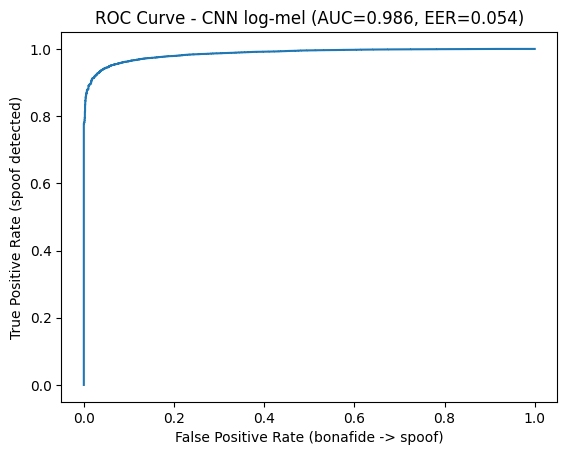

In [34]:
# CELL 3: ROC/AUC + EER evaluation for CNN on DEV

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix, classification_report

# load best checkpoint
model.load_state_dict(torch.load(best_ckpt, map_location=device))
model.eval()

@torch.no_grad()
def get_dev_scores(model, loader):
    all_scores = []
    all_y = []
    for x, y in tqdm(loader, desc="scoring", leave=False):
        x = x.to(device, non_blocking=True)
        logits = model(x)
        scores = torch.sigmoid(logits).cpu().numpy()  # probability spoof
        all_scores.append(scores)
        all_y.append(y.numpy())
    return np.concatenate(all_y), np.concatenate(all_scores)

def compute_eer(y_true, scores):
    fpr, tpr, thresholds = roc_curve(y_true, scores, pos_label=1)
    fnr = 1 - tpr
    idx = np.nanargmin(np.abs(fpr - fnr))
    eer = (fpr[idx] + fnr[idx]) / 2.0
    thr = thresholds[idx]
    return eer, thr, fpr, tpr

y_true, scores = get_dev_scores(model, dev_loader)
auc = roc_auc_score(y_true, scores)
eer, thr, fpr, tpr = compute_eer(y_true, scores)

y_pred = (scores >= thr).astype(int)

print("=== CNN (log-mel) on DEV ===")
print(f"AUC: {auc:.4f}")
print(f"EER: {eer:.4f} (threshold={thr:.6f})")
print("Confusion matrix @EER threshold:\n", confusion_matrix(y_true, y_pred))
print("\nClassification report @EER threshold:\n", classification_report(y_true, y_pred, target_names=["bonafide", "spoof"]))

plt.figure()
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate (bonafide -> spoof)")
plt.ylabel("True Positive Rate (spoof detected)")
plt.title(f"ROC Curve - CNN log-mel (AUC={auc:.3f}, EER={eer:.3f})")
plt.show()


In [36]:
# CELL: Save DEV scores with attack metadata (cached)

from pathlib import Path
import numpy as np
import pandas as pd

SCORE_DIR = Path("/content/drive/MyDrive/deepfake_audio/results")
SCORE_DIR.mkdir(parents=True, exist_ok=True)

score_file = SCORE_DIR / "dev_scores_with_meta.csv"

if score_file.exists():
    print("Loading cached DEV scores...")
    dev_scores_df = pd.read_csv(score_file)
else:
    print("Computing DEV scores (one-time)...")

    # Load best checkpoint
    model.load_state_dict(torch.load(best_ckpt, map_location=device))
    model.eval()

    all_scores = []
    all_labels = []

    with torch.no_grad():
        for x, y in tqdm(dev_loader, desc="Scoring DEV"):
            x = x.to(device)
            logits = model(x)
            scores = torch.sigmoid(logits).cpu().numpy()
            all_scores.append(scores)
            all_labels.append(y.numpy())

    scores = np.concatenate(all_scores)
    labels = np.concatenate(all_labels)

    # Merge with original dev_df
    dev_scores_df = dev_df.copy().reset_index(drop=True)
    dev_scores_df["score"] = scores
    dev_scores_df["label"] = labels

    dev_scores_df.to_csv(score_file, index=False)
    print("Saved scores to:", score_file)

print("DEV score dataframe shape:", dev_scores_df.shape)


Computing DEV scores (one-time)...


Scoring DEV:   0%|          | 0/389 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
Scoring DEV: 100%|██████████| 389/389 [20:15<00:00,  3.13s/it]


Saved scores to: /content/drive/MyDrive/deepfake_audio/results/dev_scores_with_meta.csv
DEV score dataframe shape: (24844, 7)


In [39]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/deepfake_audio/results/dev_scores_with_meta.csv")

print(df.columns)
print(df["attack_id"].value_counts().head())
print(df["attack_id"].unique()[:10])


Index(['speaker_id', 'file_id', 'env_id', 'attack_id', 'label_str', 'score',
       'label'],
      dtype='object')
attack_id
A01    3716
A02    3716
A03    3716
A05    3716
A04    3716
Name: count, dtype: int64
['-' 'A01' 'A02' 'A03' 'A04' 'A05' 'A06']


In [40]:
# CELL: Correct per-attack EER analysis (spoof attack vs all bonafide)

from sklearn.metrics import roc_curve, roc_auc_score
import numpy as np
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/deepfake_audio/results/dev_scores_with_meta.csv")

def compute_eer(y_true, scores):
    fpr, tpr, thresholds = roc_curve(y_true, scores, pos_label=1)
    fnr = 1 - tpr
    idx = np.nanargmin(np.abs(fpr - fnr))
    eer = (fpr[idx] + fnr[idx]) / 2.0
    return eer

results = []

# Separate bonafide once (reuse)
bonafide_df = df[df["attack_id"] == "-"]

for attack in sorted(df["attack_id"].unique()):
    if attack == "-":
        continue  # skip bonafide label

    spoof_subset = df[df["attack_id"] == attack]

    # Combine this attack's spoof with ALL bonafide
    combined = pd.concat([bonafide_df, spoof_subset])

    y = combined["label"].values
    s = combined["score"].values

    auc = roc_auc_score(y, s)
    eer = compute_eer(y, s)

    results.append({
        "attack_id": attack,
        "samples_spoof": len(spoof_subset),
        "AUC": auc,
        "EER": eer
    })

attack_results_df = pd.DataFrame(results).sort_values("EER")

attack_results_file = "/content/drive/MyDrive/deepfake_audio/results/per_attack_results.csv"
attack_results_df.to_csv(attack_results_file, index=False)

print("Saved attack analysis to:", attack_results_file)
attack_results_df


Saved attack analysis to: /content/drive/MyDrive/deepfake_audio/results/per_attack_results.csv


,attack_id,samples_spoof,AUC,EER
1,A02,3716,1.000000,0.000000
2,A03,3716,0.999996,0.001788
0,A01,3716,0.999974,0.002792
4,A05,3716,0.998059,0.013388
3,A04,3716,0.984242,0.055387
5,A06,3716,0.936411,0.133396


# Experiment: Temporal Modeling to Improve A06 Detection


In [ ]:
# CELL: CNN + GRU model to improve A06 detection

import torch
import torch.nn as nn
import torch.nn.functional as F
from pathlib import Path
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


class CNN_GRU_Model(nn.Module):
    def __init__(self):
        super().__init__()

        # CNN feature extractor
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Dropout(0.3)
        )

        # GRU for temporal modeling
        self.gru = nn.GRU(
            input_size=128 * (N_MELS // 4),
            hidden_size=128,
            num_layers=1,
            batch_first=True,
            bidirectional=True
        )

        self.classifier = nn.Linear(256, 1)

    def forward(self, x):
        x = self.cnn(x)  # (B, C, H, T)

        B, C, H, T = x.shape

        # reshape for GRU
        x = x.permute(0, 3, 1, 2)   # (B, T, C, H)
        x = x.reshape(B, T, C * H)  # (B, T, features)

        out, _ = self.gru(x)

        # use last time step
        out = out[:, -1, :]

        logits = self.classifier(out).squeeze(1)
        return logits


model = CNN_GRU_Model().to(device)


# Focal Loss
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        prob = torch.sigmoid(logits)
        pt = torch.where(targets == 1, prob, 1 - prob)
        loss = self.alpha * (1 - pt) ** self.gamma * bce
        return loss.mean()

criterion = FocalLoss(alpha=0.75, gamma=2.0)

optimizer = torch.optim.Adam(model.parameters(), lr=5e-4, weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=2
)


def train_one_epoch(model, loader):
    model.train()
    total_loss = 0
    n = 0

    for x, y in tqdm(loader, desc="train", leave=False):
        x = x.to(device)
        y = y.to(device).float()

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        n += x.size(0)

    return total_loss / n


@torch.no_grad()
def eval_loss(model, loader):
    model.eval()
    total_loss = 0
    n = 0

    for x, y in tqdm(loader, desc="dev", leave=False):
        x = x.to(device)
        y = y.to(device).float()

        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item() * x.size(0)
        n += x.size(0)

    return total_loss / n


EPOCHS = 20
best_dev = float("inf")

best_path = Path("/content/drive/MyDrive/deepfake_audio/models")
best_ckpt = best_path / "cnn_gru_best.pt"

for epoch in range(1, EPOCHS + 1):
    tr_loss = train_one_epoch(model, train_loader)
    dv_loss = eval_loss(model, dev_loader)

    scheduler.step(dv_loss)

    print(f"Epoch {epoch}/{EPOCHS} | train_loss={tr_loss:.4f} | dev_loss={dv_loss:.4f}")

    if dv_loss < best_dev:
        best_dev = dv_loss
        torch.save(model.state_dict(), best_ckpt)
        print("Saved best checkpoint:", best_ckpt)

print("Training done. Best dev loss:", best_dev)


Device: cpu


train:   0%|          | 0/397 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
train:  84%|████████▍ | 333/397 [52:08<09:53,  9.28s/it]